In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

In [2]:
# Column names based on UCI heart disease dataset documentation
columns =['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# Load data (handling '?' as missing values)
df = pd.read_csv('../data/heart.csv', names=columns, na_values='?')

# Convert target variable to binary (0 = no disease, 1 = disease)
# In the original dataset, 1, 2, 3, 4 represent different levels of heart disease
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Display the first 5 rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
# Check dataset info (data types and missing values)
print("Dataset Information:")
df.info()

print("\nMissing Values Count:")
print(df.isnull().sum())

# Basic statistics
df.describe()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

Missing Values Count:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
targ

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


C:\Users\aybek\AppData\Local\Temp\ipykernel_5812\3489555098.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='Set2')


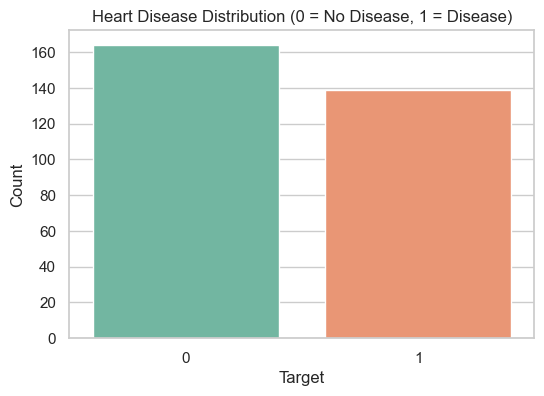

Target Value Counts:
target
0    164
1    139
Name: count, dtype: int64


In [4]:
# Visualize the target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='Set2')
plt.title('Heart Disease Distribution (0 = No Disease, 1 = Disease)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

print("Target Value Counts:")
print(df['target'].value_counts())

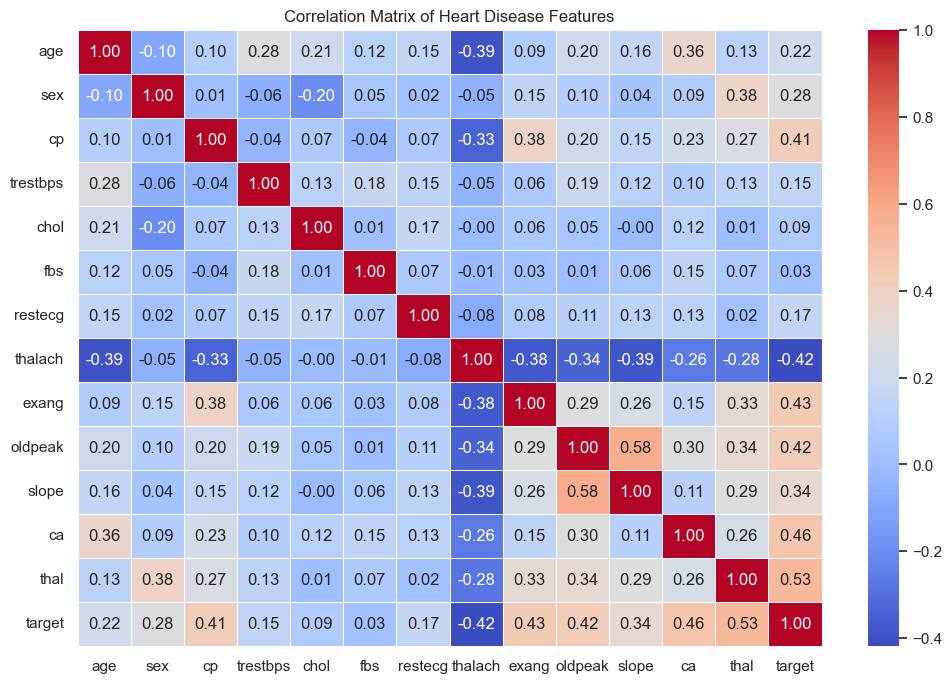

In [5]:
# Correlation Matrix to see which features affect the target most
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Heart Disease Features')
plt.show()

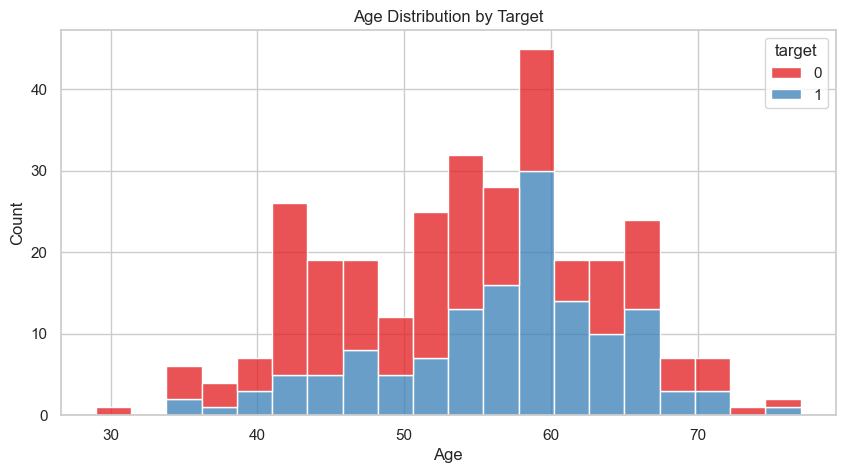

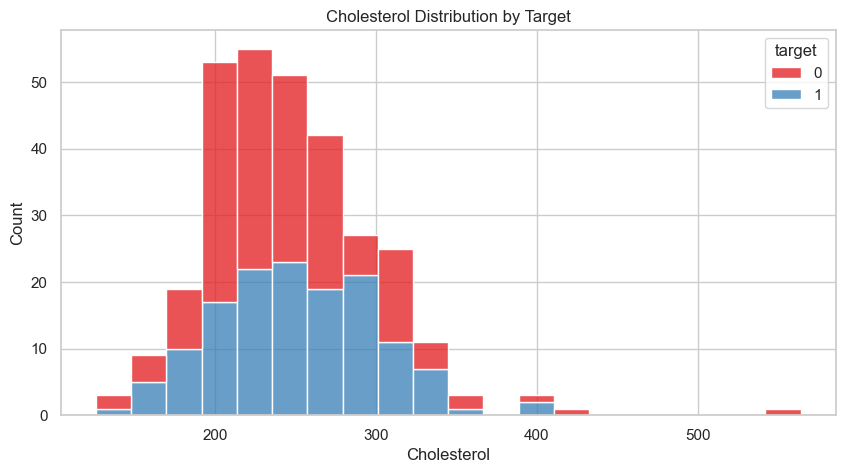

In [6]:
# Age vs Target
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='target', multiple='stack', bins=20, palette='Set1')
plt.title('Age Distribution by Target')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Cholesterol vs Target
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='chol', hue='target', multiple='stack', bins=20, palette='Set1')
plt.title('Cholesterol Distribution by Target')
plt.xlabel('Cholesterol')
plt.ylabel('Count')
plt.show()

In [7]:
# Fill missing values in 'ca' and 'thal' with their median values
df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())

# Verify there are no missing values left
print("Missing values after imputation:")
print(df.isnull().sum().max() == 0) # Should output True

Missing values after imputation:
True


In [8]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split into training (80%) and testing (20%) sets
# stratify=y ensures the same proportion of 0s and 1s in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (242, 13)
Testing Data Shape: (61, 13)


In [9]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to keep column names (useful for Model Explainability later)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Display the scaled training data
X_train_scaled.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.729485,0.68313,0.870169,-0.395692,0.458139,-0.411196,1.022996,0.708371,-0.696177,-0.445445,0.675060,-0.689715,1.179973
1,0.050166,0.68313,-1.184278,-0.054513,0.230598,-0.411196,-0.981579,0.222495,-0.696177,-0.891627,-0.958585,-0.689715,-0.878070
2,-0.061212,-1.46385,-1.184278,0.059213,0.723605,2.431930,1.022996,0.399178,1.436416,-0.891627,-0.958585,0.445734,-0.878070
3,-0.061212,0.68313,-1.184278,-1.305501,1.121803,-0.411196,-0.981579,0.266666,-0.696177,-0.891627,-0.958585,-0.689715,1.179973
4,0.272924,-1.46385,0.870169,0.514117,-0.167601,-0.411196,-0.981579,-1.190962,1.436416,-0.713154,0.675060,-0.689715,1.179973


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Initialize the models
# Note: probability=True in SVC is needed for ROC curve later
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Dictionary to store trained models
trained_models = {}

# Train (fit) each model using the training data
print("Training progress:")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f" - {name} trained successfully.")

Training progress:
 - Logistic Regression trained successfully.
 - KNN trained successfully.
 - SVM trained successfully.
 - Random Forest trained successfully.


In [11]:
from sklearn.metrics import accuracy_score

print("\nModel Evaluation (Accuracy on Test Data):")
results = {}

for name, model in trained_models.items():
    # Make predictions on the unseen test data
    y_pred = model.predict(X_test_scaled)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")


Model Evaluation (Accuracy on Test Data):
Logistic Regression Accuracy: 0.8689
KNN Accuracy: 0.8852
SVM Accuracy: 0.8525
Random Forest Accuracy: 0.8852


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61



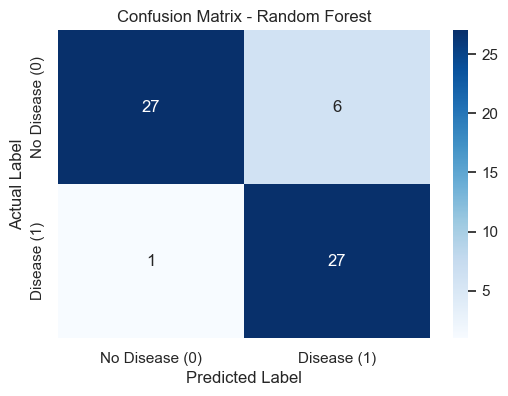

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

best_model = trained_models["Random Forest"]
y_pred_rf = best_model.predict(X_test_scaled)

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease (0)', 'Disease (1)'], yticklabels=['No Disease (0)', 'Disease (1)'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

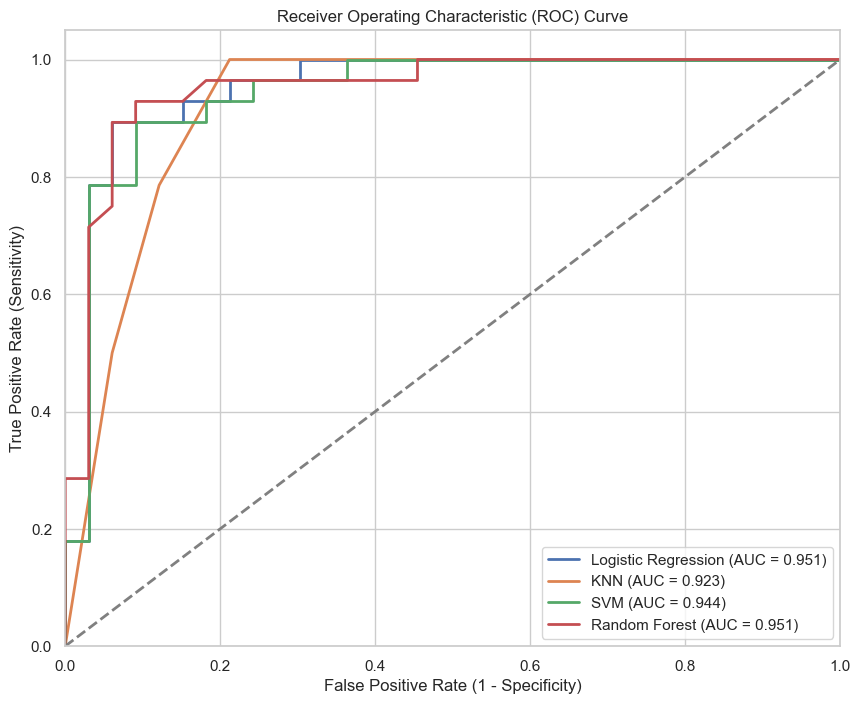

In [13]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for name, model in trained_models.items():
    # Get prediction probabilities for the positive class (Disease = 1)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate False Positive Rate and True Positive Rate
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve for each model
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Plot the random guess line
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

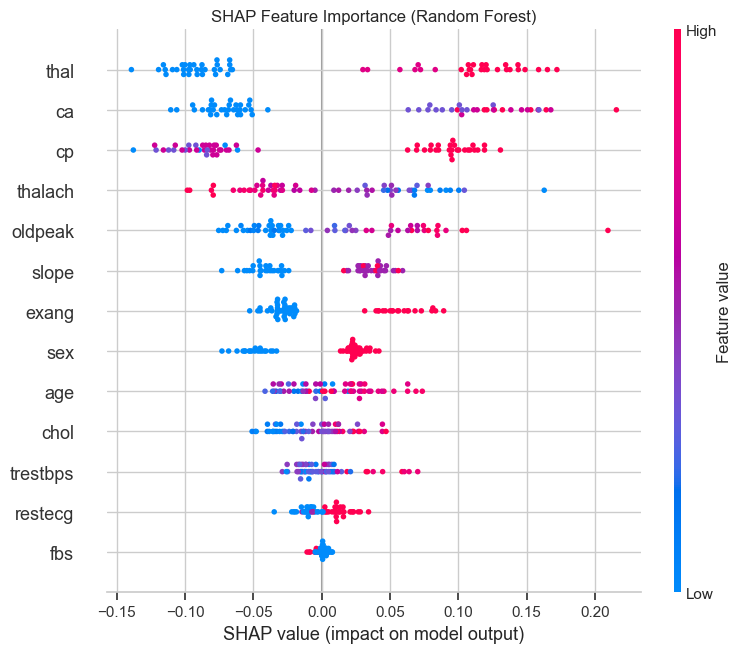

In [14]:
import shap

# Initialize JavaScript visualizations in Jupyter
shap.initjs()

# Create object that can calculate shap values for our random forest model
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled)

# Determine the correct shap values to plot (depends on shap version)
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1] # Index 1 for 'Disease' class
elif len(shap_values.shape) == 3:
    shap_values_to_plot = shap_values[:, :, 1]
else:
    shap_values_to_plot = shap_values

# Plot summary
plt.title('SHAP Feature Importance (Random Forest)')
shap.summary_plot(shap_values_to_plot, X_test_scaled, show=False)
plt.show()

In [15]:
import joblib
import os

# Create 'app' folder if it doesn't exist
os.makedirs('../app', exist_ok=True)

# Save the best model (Random Forest) and the scaler
joblib.dump(best_model, '../app/rf_model.pkl')
joblib.dump(scaler, '../app/scaler.pkl')

print("Model and Scaler saved successfully in the 'app' folder!")

Model and Scaler saved successfully in the 'app' folder!
